In [41]:
import os.path as op
import os
import pandas as pd
import numpy as np
from glob import glob
import pickle
import matplotlib.pyplot as plt

In [3]:
analysis_dir = '/global/homes/m/mphagen/functional-connectivity/connectome-comparison/scripts/notebooks/02-Analysis'

In [4]:
lasso_mat = np.loadtxt(op.join(analysis_dir, 'msmall_lasso_mean.txt') ) 

In [5]:
qcfc_raw = pd.read_csv(op.join(analysis_dir, 'msmall_lasso_qcfc.csv') ) 

In [6]:
qcfc_mat = np.array(qcfc_raw['correlation']).reshape(100,100)

In [7]:
pearson_qcfc_raw = pd.read_csv(op.join(analysis_dir, 
        'msmall_pearson_qcfc.csv'))

In [8]:
pearson_qcfc_mat = np.array(pearson_qcfc_raw['correlation']).reshape(100, 100)

In [9]:
results_dir = '/global/homes/m/mphagen/functional-connectivity/connectome-comparison/results/MSMAll'

In [10]:
corr_pkl = glob(op.join(results_dir,  '*correlation_*.pkl') ) 

In [59]:
lasso_acc_df = pd.read_csv('/global/homes/m/mphagen/functional-connectivity/connectome-comparison/results/intermediate_results/2025-12-10_r2_lasso_xcpd.csv')

In [37]:
lasso_icc_df = pd.read_csv('/global/homes/m/mphagen/functional-connectivity/connectome-comparison/results/intermediate_results/lasso_msmall_icc_df.csv')

In [61]:
#instead of subseting, come back and average over folds
lasso_acc_df = lasso_acc_df.loc[lasso_acc_df['fold'] == 'fold_0'].drop('fold', axis=1).set_index('node') 

In [62]:
lasso_acc_df.head() 

,sub-102109,sub-930449,sub-342129,sub-159441,sub-205220,sub-673455,sub-204521,sub-130316,sub-134425,sub-141422,...,sub-870861,sub-867468,sub-130013,sub-118225,sub-406432,sub-129533,sub-601127,sub-111413,sub-579665,sub-454140
node,,,,,,,,,,,,,,,,,,,,,
node_0,0.030040,0.448278,-0.116561,0.136001,0.298187,0.357999,0.227592,0.022722,0.377636,0.110304,...,0.414538,-0.137033,0.301801,0.110730,0.009882,-0.595706,0.262630,0.250562,0.230224,0.024896
node_1,0.748261,0.627693,0.100757,-0.095523,0.784822,0.531821,0.233194,0.535213,0.679995,0.530980,...,0.143089,0.206400,0.423141,0.328194,-0.063409,-0.266261,0.469322,0.566786,0.437656,0.416118
node_2,0.597836,0.680403,0.233722,0.304437,0.800197,0.679589,0.050633,0.604727,0.673433,0.488510,...,0.715986,0.182490,0.520776,0.101023,0.525987,-0.286898,0.742945,0.475739,0.781964,0.396461
node_3,0.230424,0.524522,0.477725,0.188595,0.503117,0.272677,0.363956,0.450158,0.316723,0.263236,...,0.023630,0.649350,0.251995,-0.028843,-0.946123,-0.143383,0.567333,0.404566,0.533064,0.531681
node_4,0.475551,0.636229,-0.569483,-0.168427,0.731369,0.558744,0.433007,0.046691,0.709539,0.211340,...,0.068803,0.124420,0.406778,0.234246,-0.875454,-0.097750,0.262854,0.521679,0.453749,0.474812


In [76]:
corr_list = [] 
for ii in lasso_acc_df.index: 
    corr_list.append(pd.DataFrame([lasso_acc_df.loc[ii], qa_df['RL_1']]).T.corr().iloc[0,1])

In [79]:
np.mean(corr_list) 

#what is the anatomical specificity of this? 

np.float64(-0.12651320299937438)

(array([ 4.,  5., 10., 13., 23., 10., 15., 11.,  5.,  4.]),
 array([-2.85182687e-01, -2.53467377e-01, -2.21752067e-01, -1.90036757e-01,
        -1.58321447e-01, -1.26606137e-01, -9.48908266e-02, -6.31755165e-02,
        -3.14602064e-02,  2.55103762e-04,  3.19704139e-02]),
 <BarContainer object of 10 artists>)

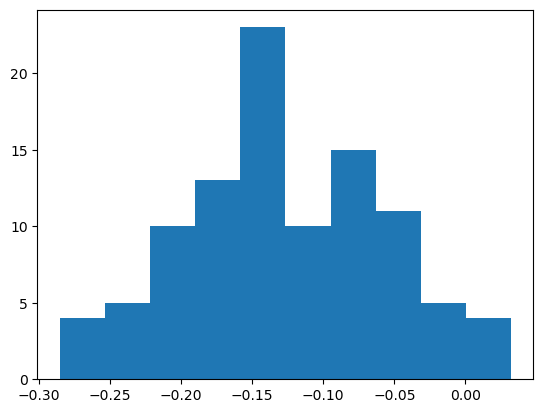

In [80]:
plt.hist(corr_list) 

In [25]:
lasso_acc_mat = lasso_acc_df.drop(['fold', 'node'], axis=1).mean(axis=1)

In [63]:
qa_df

,RL_1,RL_2,LR_2,LR_1
sub-102109,0.059823,0.042828,0.044440,0.053946
sub-102311,0.077215,0.115734,0.126213,0.081149
sub-103010,0.089317,0.069989,0.071405,0.091660
sub-105014,0.089773,0.061629,0.068861,0.067719
sub-107018,0.086903,0.091048,0.098031,0.077306
...,...,...,...,...
sub-930449,0.085005,0.077719,0.076536,0.083291
sub-937160,0.147575,0.159833,0.145389,0.144399
sub-947668,0.155752,0.269681,0.209413,0.175215
sub-959574,0.077039,0.054227,0.055480,0.045388


In [36]:
node_qcfc = abs(qcfc_mat).sum(axis=0)

In [35]:
np.corrcoef(lasso_acc_mat.ravel(), node_qcfc.ravel())

/tmp/ipykernel_160989/2197132313.py:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  np.corrcoef(lasso_acc_mat.ravel(), node_qcfc.ravel())


array([[1.        , 0.22147521],
       [0.22147521, 1.        ]])

In [ ]:
np.corrcoef(lasso_acc_mat.ravel(), node_qcfc.ravel())

In [12]:
with open(corr_pkl[0], 'rb') as file: 
    msmall_corr_dict = pickle.load(file)

    

In [13]:
msmall_corr_mat = np.zeros((100,100, 0))

for sub in msmall_corr_dict.keys():
    # for ses in msmall_dict[participant].keys():
    temp_mat = msmall_corr_dict[sub]['ses-full']
    np.fill_diagonal(temp_mat, 0)
    msmall_corr_mat = np.dstack((msmall_corr_mat, temp_mat)  )

In [14]:
msmall_corr_mat.shape

(100, 100, 96)

In [15]:
msmall_corr_mean_mat = np.mean(msmall_corr_mat, axis=2) 

In [16]:
np.corrcoef(msmall_corr_mean_mat.ravel(), qcfc_mat.ravel()) 

array([[ 1.        , -0.06338484],
       [-0.06338484,  1.        ]])

In [17]:
# with open(op.join(analysis_dir, 'msmall_pearson_icc.pkl'), 'rb') as file:
#     msmall_pearson_icc_dict = pickle.load( file)

In [20]:
msmall_pearson_icc = [] 
for ii in range(1,10001): 
    msmall_pearson_icc.append(msmall_pearson_icc_dict[ii].loc[5]['ICC']) 
msmall_pearson_icc = np.array(msmall_pearson_icc).reshape(100,100)

In [48]:
with open(op.join(analysis_dir, 'msmall_lasso_icc.pkl'), 'rb') as file:
    msmall_lasso_icc_dict = pickle.load( file)

In [49]:
msmall_lasso_icc = [] 
for ii in range(1,10001): 
    msmall_lasso_icc.append(msmall_lasso_icc_dict[ii].loc[5]['ICC']) 
msmall_lasso_icc = np.array(msmall_lasso_icc).reshape(100,100)

In [53]:
qa_df = pd.read_csv('/global/homes/m/mphagen/functional-connectivity/connectome-comparison/data/relative_movement.csv', 
                    index_col=0).sort_index()
qa_df.index = [f'sub-{i}' for i in qa_df.index] 
print(qa_df.shape, qa_df.columns)

(100, 4) Index(['RL_1', 'RL_2', 'LR_2', 'LR_1'], dtype='object')


In [1]:
pd.DataFrame(msmall_lasso_icc.ravel(), lasso_acc_mat.ravel()).T.coor() 

NameError: name 'pd' is not defined

In [26]:
pd.DataFrame([msmall_lasso_icc.ravel(), lasso_mat.ravel()]).T.corr()

,0,1
0,1.000000,0.372079
1,0.372079,1.000000


In [27]:
pd.DataFrame([msmall_pearson_icc.ravel(), pearson_qcfc_mat.ravel()]).T.corr()

,0,1
0,1.000000,-0.103824
1,-0.103824,1.000000
